# NextGEMS data

| [![NextGEMS-badge]][NextGEMS-url] |
|:-:|

[NextGEMS-badge]: https://img.shields.io/badge/NextGEMS-grey?style=for-the-badge&logo=readthedocs&logoColor=white
[NextGEMS-url]: https://easy.gems.dkrz.de/DYAMOND/NextGEMS/index.html

## Experiment Details and Available Data Fields

The dataset comprises output data from an ICON run within the 4th model cycle phase of the NextGEMS project (NGC4008). This simulation spans a total of 30 years and uses an ssp370-like scenario run from 2020.
The simulation was performed using a horizontal grid spacing of approximately 100 km (R2B8/8). 
A global, coupled simulation covering a time period of 1000 years, starting in 1300, was run. 48-hourly output data were generated throughout the simulation.
However, only a subset of the data is provided: three months of data for four selected variables at three model levels.
The data are stored on a HEALPix grid with lossless compression, and the total size of the available dataset is approximately 9 GB.

The dataset is contained in a Zarr directory. The data are available for reuse under the Creative Commons Attribution 4.0 International (CC BY 4.0) license: <https://creativecommons.org/licenses/by/4.0/>.

The following 2D parameters are available:
```python
["hus", "pr", "ua", "va"]
```
The following model levels are available:
```python
[89, 65, 55]
```


The available time steps begin at 2020-01-02 00:00:00 UTC, increasing in 2-day steps until 2020-03-31 00:00:00 UTC.



## Using the `load_NextGEMS_data` Function

To load the Zarr directory, you can use the following function:

```python
load_NextGEMS_data()
```

This function is straightforward and does not require any parameters.


In [1]:
import sys

sys.path.insert(0, "..")

In [2]:
# URL of S3 bucket
BASE_URL = "https://object-store.os-api.cci1.ecmwf.int/esiwacebucket"

First, the package `zarr` (modern dataset format that is specifically designed for chunked access) and its dependencies need to be imported for the remote access.

The `load_NextGEMS_data` function simplifies remote access to Zarr datasets stored on the S3 bucket. It loads the data efficiently as an xarray dataset.


In [3]:
import xarray as xr


def load_NextGEMS_data():
    url = f"{BASE_URL}/EW3_ICON_ngc4008_90d_Compression_test.zarr"

    print(f"Loading dataset {url}")

    return xr.open_dataset(url, engine="zarr", chunks={})

## Example Usage

To load the Zarr directory, you can use the following example. This will load the whole dataset. 

In [4]:
ds = load_NextGEMS_data()
ds

Loading dataset https://object-store.os-api.cci1.ecmwf.int/esiwacebucket/EW3_ICON_ngc4008_90d_Compression_test.zarr


<xarray.Dataset> Size: 11GB
Dimensions:     (time: 90, level_full: 3, cell: 3145728)
Coordinates:
  * time        (time) datetime64[ns] 720B 2020-01-02 2020-01-03 ... 2020-03-31
  * level_full  (level_full) float64 24B 89.0 65.0 55.0
Dimensions without coordinates: cell
Data variables:
    hus         (time, level_full, cell) float32 3GB dask.array<chunksize=(3, 1, 196608), meta=np.ndarray>
    pr          (time, cell) float32 1GB dask.array<chunksize=(3, 196608), meta=np.ndarray>
    ua          (time, level_full, cell) float32 3GB dask.array<chunksize=(3, 1, 196608), meta=np.ndarray>
    va          (time, level_full, cell) float32 3GB dask.array<chunksize=(3, 1, 196608), meta=np.ndarray>

The `earthkit.plots` package is used for plotting the data.

In [5]:
import earthkit.plots

from utils import quickplot

The data on the HEALPix grid can be visualized as demonstrated below. For example, the specific humidity on **2020-02-01 at 00:00:00 UTC** at model level 89 is plotted.

In [6]:
da_hus = ds.hus.sel(time="2020-02-01T00:00:00", level_full=89.0)

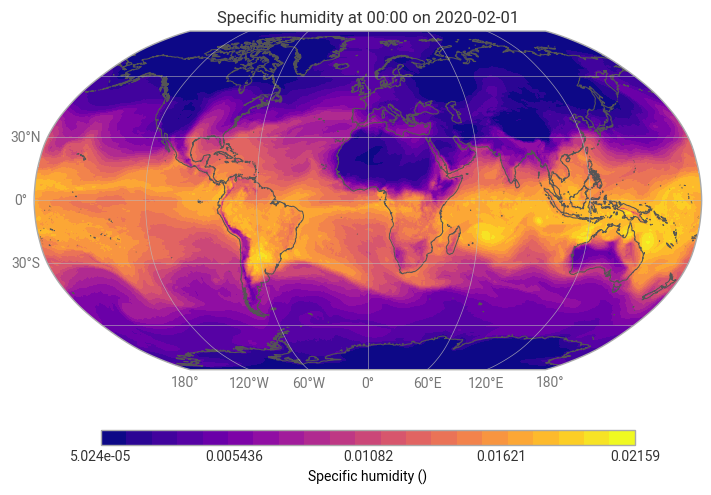

In [7]:
gridspec = {
    "type": "healpix",
    "grid": "H512",
    "ordering": "nested",
}

quickplot(da_hus, method="quickplot", chart=earthkit.plots.Map(crs="Robinson"), metadata={"gridSpec": gridspec})

The `pyicon` library can also be used to visualize the data as demonstrated below.

----Start loading pyicon.
Loading default parameters from /Users/junityre/compression-lab-notebooks/.venv/lib/python3.14/site-packages/pyicon/params_default.json.
----Start loading pyicon.
----Pyicon was loaded successfully.
----Pyicon was loaded successfully.


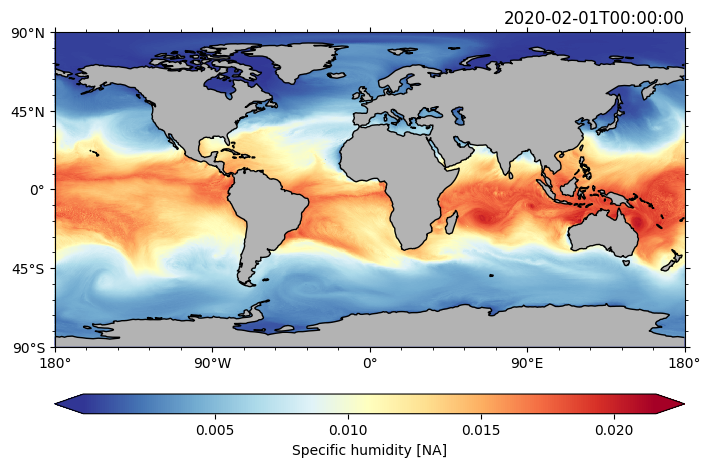

In [8]:
import matplotlib.pyplot as plt
import pyicon as pyic

da_hus.pyic.plot()
plt.show()

Zonal and Meridional wind can be visualized in the same way.


The precipitation flux on **2020-03-31 at 00:00:00 UTC** is plotted as demonstrated below.


In [9]:
da_pr = ds.pr.sel(time="2020-03-31T00:00:00")

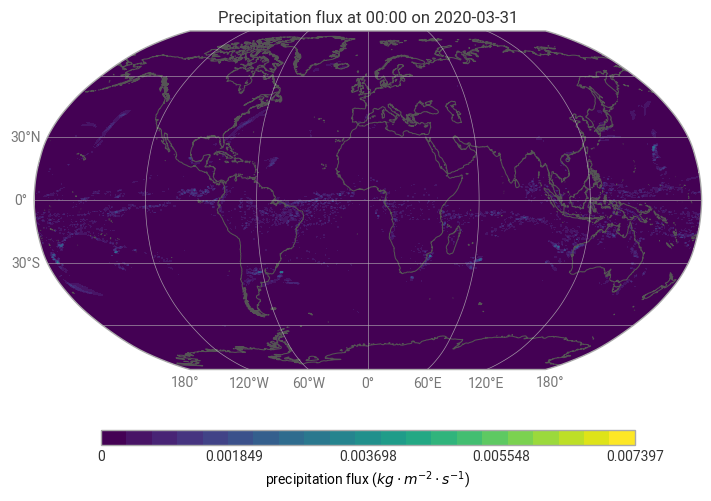

In [10]:
quickplot(da_pr, method="quickplot", chart=earthkit.plots.Map(crs="Robinson"), metadata={"gridSpec": gridspec})

The visualization with `pyicon` is shown below.

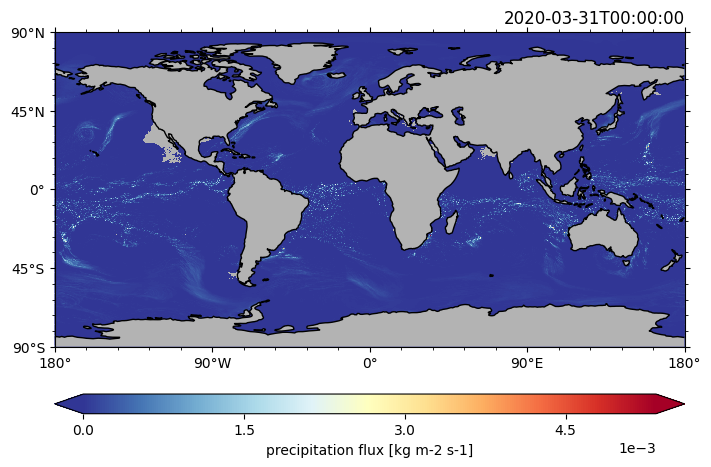

In [11]:
da_pr.pyic.plot()
plt.show()